# Dataset description
## Child labor by reason

**Source**: DANE

**Dataset**: [GEIH](https://www.dane.gov.co/index.php/estadisticas-por-tema/mercado-laboral/trabajo-infantil)

# Code
## Imports

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

## Load data

In [28]:
path = "./data/razon.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [36]:
df_f = df[
    (df["Fecha"].eq(2025)) &
    (df["Perspectiva"].eq("Total nacional")) &
    (~df["Concepto"].str.contains("Población"))
]

reasons_series = df_f.set_index("Concepto")["Valor"].sort_values(ascending=True)

reasons_translations = {
    "Debe ayudar con los gastos de la casa, ayudar a costearse el estudio": "Should help with household\nexpenses, help pay for studies",
    "Porque el trabajo lo forma, lo hace honrado y lo aleja de los vicios": "Because work shapes them, makes\nthem honorable and keeps\nthem away from vices",
    "Debe participar en la actividad económica de la familia": "Should participate in the\nfamily economic activity",
    "Le gusta trabajar para tener su propio dinero": "They like working to\nhave their own money",
    "Otra razón": "Other reason"
}

reasons_series.index = reasons_series.index.map(reasons_translations)

## Plot

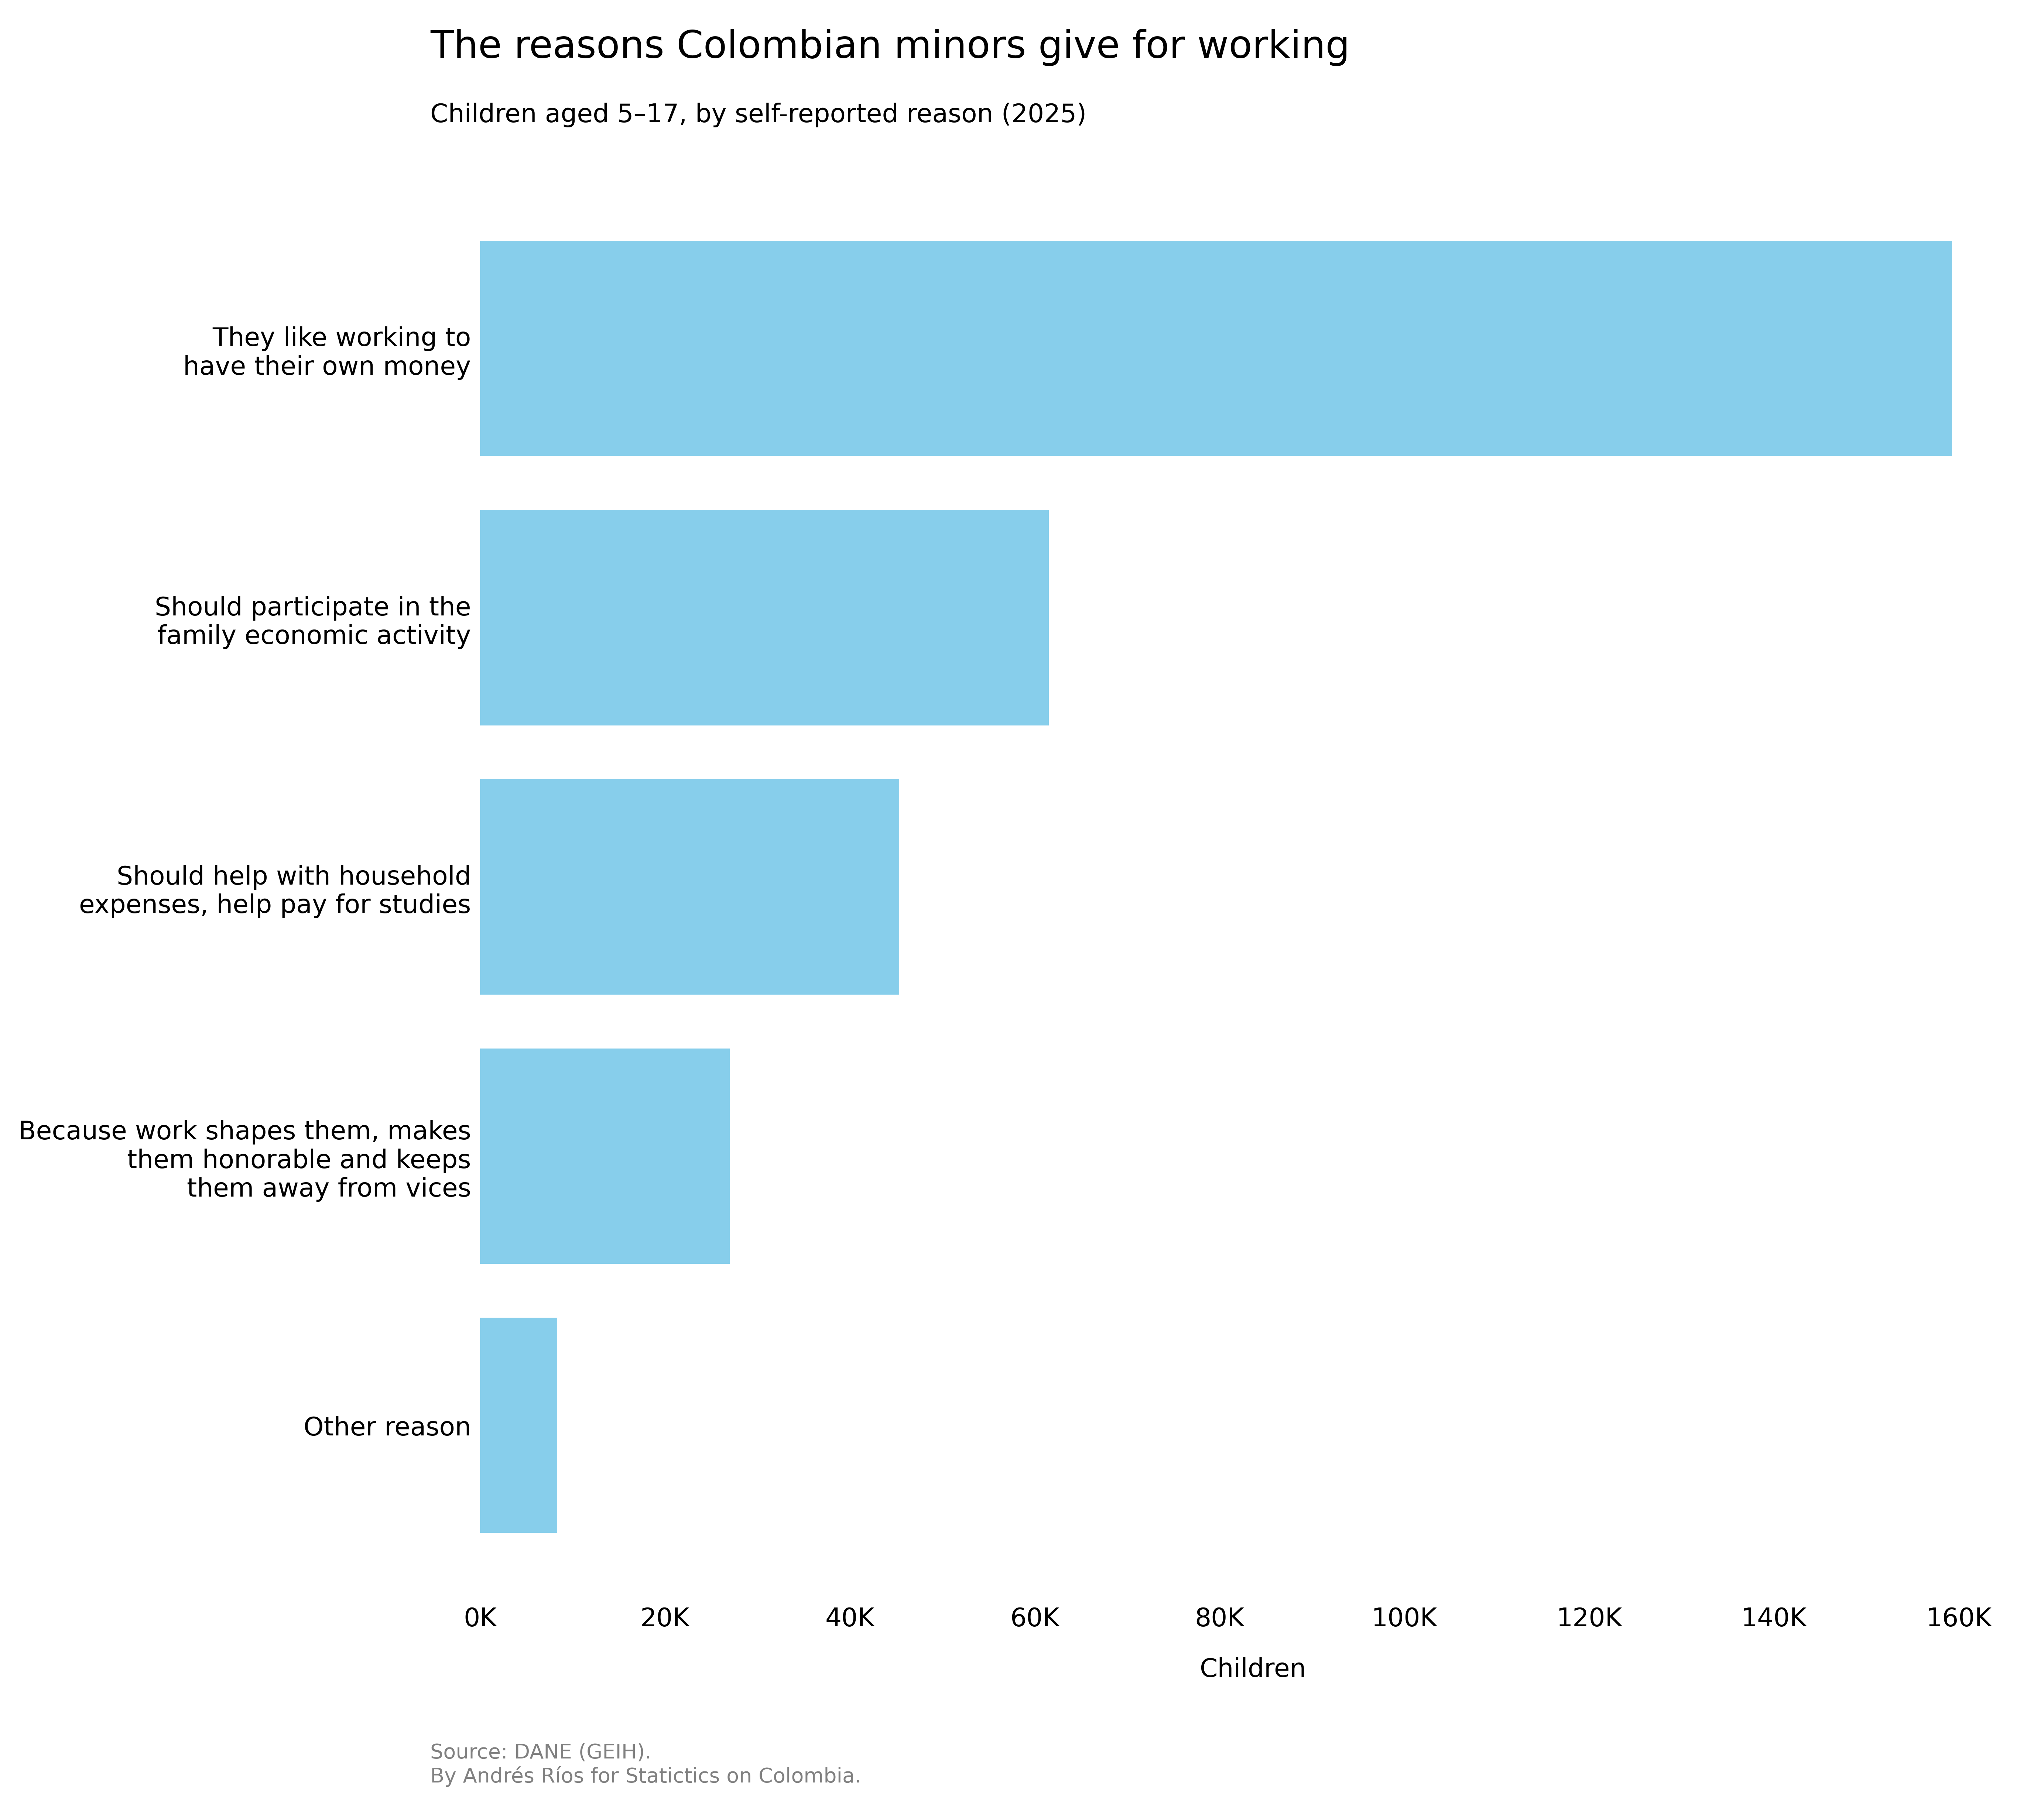

In [49]:
plt.figure(figsize=(10.8, 10), dpi=500)

plt.barh(reasons_series.index, reasons_series.values, color="skyblue")

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}K"))

plt.xlabel("Children", labelpad=10, fontsize=10)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

fig_text(
    0.1, 0.96,
    s="The reasons Colombian minors give for working",
    fontsize=15,
)

fig_text(
    0.1, 0.92,
    s="Children aged 5–17, by self-reported reason (2025)",
    fontsize=10,
)

fig = plt.gcf()
fig.text(
    0.1, 0.01, 
    "Source: DANE (GEIH).\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
) 

plt.show()